# Weekly Shrinkage – Mid-Atlantic Locations

This notebook replicates a ggplot2-style visualization in Python using **pandas**, **matplotlib**, and **seaborn**. It compares weekly shrinkage percentages for the years **2020–2022**.

In [13]:
# --- Import Required Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

## Create the dataset

In [15]:
# --- Sample Data ---
weeks = [f"WK{i}" for i in range(1, 54)]

shrinkage_data = pd.DataFrame({
    "Week": weeks,
    "Shrinkage_2020": [1.70, 1.65, 1.60, 1.55, 1.50, 1.45, 1.35, 1.30, 1.25, 1.20,
                       1.15, 1.10, 1.05, 1.00, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20,
                       1.25, 1.30, 1.35, 1.30, 1.25, 1.20, 1.15, 1.10, 1.05, 1.00,
                       0.95, 1.00, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40,
                       1.45, 1.50, 1.55, 1.60, 1.65, 1.70, 1.75, 1.80, 1.85, 1.90,
                       1.95, 2.00, 2.05],
    "Shrinkage_2021": [1.50, 1.55, 1.60, 1.65, 1.70, 1.75, 1.70, 1.65, 1.60, 1.55,
                       1.50, 1.45, 1.40, 1.35, 1.40, 1.45, 1.50, 1.55, 1.60, 1.65,
                       1.70, 1.75, 1.80, 1.85, 1.90, 1.95, 2.00, 2.05, 2.10, 2.00,
                       1.90, 1.85, 1.80, 1.75, 1.70, 1.65, 1.60, 1.55, 1.50, 1.45,
                       1.40, 1.35, 1.30, 1.25, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45,
                       1.50, 1.55, 1.60],
    "Shrinkage_2022": [2.00, 2.05, 2.10, 2.15, 2.20, 2.25, 2.15, 2.10, 2.05, 2.00,
                       1.95, 1.90, 1.85, 1.80, 1.85, 1.90, 1.95, 2.00, 2.05, 2.00,
                       1.95, 1.90, 1.85] + [np.nan]*30
})

shrinkage_data.head()

,Week,Shrinkage_2020,Shrinkage_2021,Shrinkage_2022
0,WK1,1.70,1.50,2.00
1,WK2,1.65,1.55,2.05
2,WK3,1.60,1.60,2.10
3,WK4,1.55,1.65,2.15
4,WK5,1.50,1.70,2.20


## Reshape data for plotting

In [16]:
# --- Reshape for plotting ---
data_long = shrinkage_data.melt(id_vars="Week", 
                                var_name="Year", 
                                value_name="Shrinkage")

# Convert shrinkage to proportions (for PercentFormatter)
data_long["Shrinkage"] = data_long["Shrinkage"] / 100
data_long.head()

,Week,Year,Shrinkage
0,WK1,Shrinkage_2020,0.0170
1,WK2,Shrinkage_2020,0.0165
2,WK3,Shrinkage_2020,0.0160
3,WK4,Shrinkage_2020,0.0155
4,WK5,Shrinkage_2020,0.0150


## Plot the data

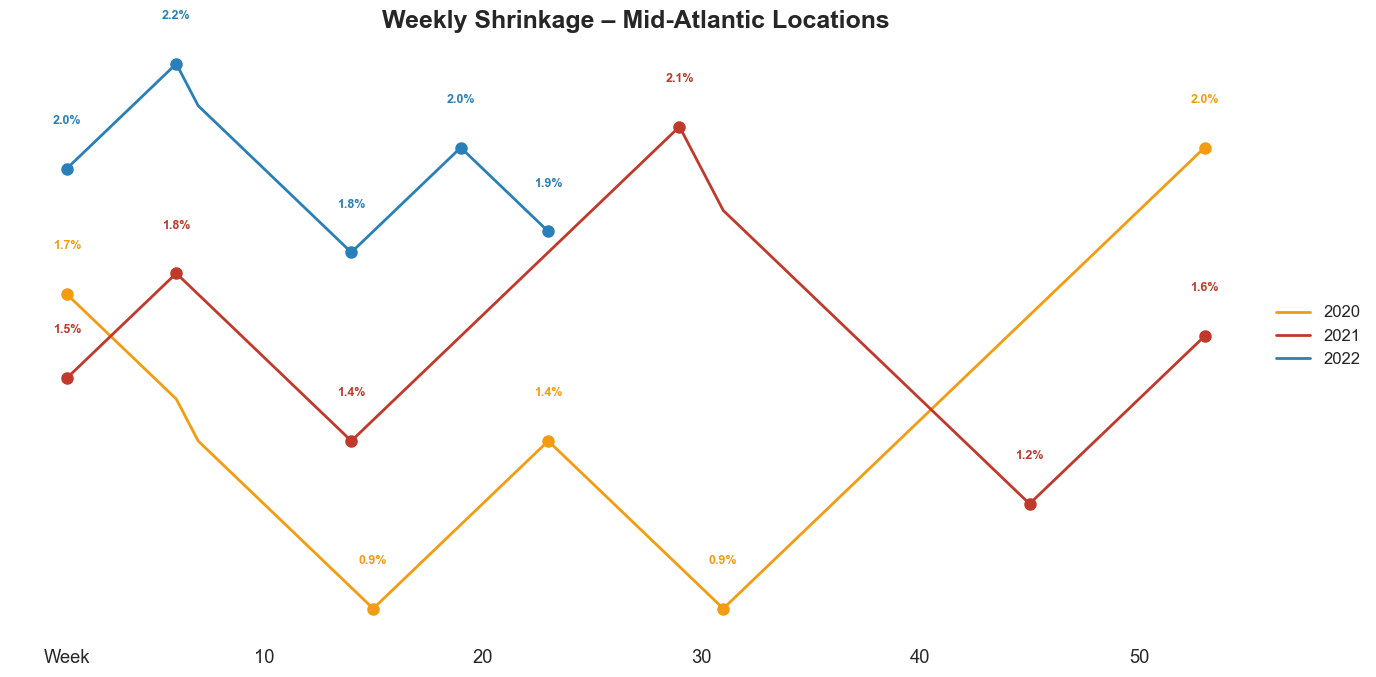

In [17]:
plt.figure(figsize=(14, 7))

palette = {
    "Shrinkage_2020": "#f39c12",
    "Shrinkage_2021": "#c0392b",
    "Shrinkage_2022": "#2980b9"
}

ax = sns.lineplot(
    data=data_long, x="Week", y="Shrinkage", hue="Year",
    palette=palette, linewidth=2, marker=None
)

for year, color in palette.items():
    year_data = shrinkage_data[['Week', year]].copy()
    year_data = year_data.dropna()
    values = year_data[year].values
    
    peaks = []
    for i in range(1, len(values) - 1):
        if (values[i] > values[i-1] and values[i] > values[i+1]) or \
           (values[i] < values[i-1] and values[i] < values[i+1]):
            peaks.append(i)
    
    if len(values) > 0:
        peaks = [0] + peaks + [len(values) - 1]
    
    for idx in peaks:
        week_idx = year_data.index[idx]
        x_pos = week_idx
        y_pos = values[idx] / 100
        
        plt.plot(x_pos, y_pos, 'o', color=color, markersize=8, zorder=5)
        plt.text(x_pos, y_pos + 0.001, f'{values[idx]:.1f}%', 
                ha='center', va='bottom', color=color, fontsize=9, fontweight='bold')

plt.yticks([])
plt.ylabel("")

plt.title("Weekly Shrinkage – Mid-Atlantic Locations", fontsize=18, weight='bold')
plt.xlabel("")

tick_positions = [0, 9, 19, 29, 39, 49]
tick_labels = ['Week', '10', '20', '30', '40', '50']
plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=0)

handles, labels = ax.get_legend_handles_labels()
new_labels = [label.replace('Shrinkage_', '') for label in labels]
plt.legend(handles, new_labels, title="", loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=12)

sns.despine(left=True, bottom=True)
plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()